<a href="https://colab.research.google.com/github/deboraluz/deboraluz/blob/main/Profissao_Cientista_de_Dados_M17_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [37]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [38]:
#A) seu código aqui
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB


In [39]:
df['Age'] = df['Age'].astype('Int64')

In [40]:
df['Income'] = (
    df['Income']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [41]:
df['Income'].dtype

dtype('float64')

In [42]:
df['Income'].head()

,Income
0,50000.0
1,100000.0
2,75000.0
3,125000.0
4,100000.0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    Int64  
 1   Gender              164 non-null    object 
 2   Income              164 non-null    float64
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: Int64(1), float64(1), int64(1), object(5)
memory usage: 10.5+ KB


Justificativa: Optei por mudar Age para inteiro pois para mim não fazia sentido ser float. E mudei Income para float pois será melhor de trabalhar entendendo ele como um número.

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [44]:
#seu código aqui
df.isnull().sum()

,0
Age,34
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


In [45]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [46]:
df.isnull().sum()

,0
Age,0
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


Justificativa: Foram encontrados 34 valores faltantes em "Age", foi substituido pela mediana pois não faria sentido preencher com 0, e a mediana é menos sensível a valores extremos.

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [47]:
#seu código aqui
for coluna in ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']:
    print(f'\n{coluna}:')
    print(df[coluna].value_counts())


Gender:
Gender
Female    86
Male      78
Name: count, dtype: int64

Education:
Education
Bachelor's Degree      42
Master's Degree        36
Doctorate              31
High School Diploma    30
Associate's Degree     25
Name: count, dtype: int64

Marital Status:
Marital Status
Married    87
Single     77
Name: count, dtype: int64

Home Ownership:
Home Ownership
Owned     111
Rented     53
Name: count, dtype: int64

Credit Score:
Credit Score
High       113
Average     36
Low         15
Name: count, dtype: int64


Justificativa: Os dados já estão padronizados.

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [48]:
#seu código aqui
df.describe()

,Age,Income,Number of Children
count,164.0,164.000000,164.000000
mean,37.195122,83765.243902,0.652439
std,7.586619,32457.306728,0.883346
min,25.0,25000.000000,0.000000
25%,31.75,57500.000000,0.000000
50%,36.0,83750.000000,0.000000
75%,43.0,105000.000000,1.000000
max,53.0,162500.000000,3.000000


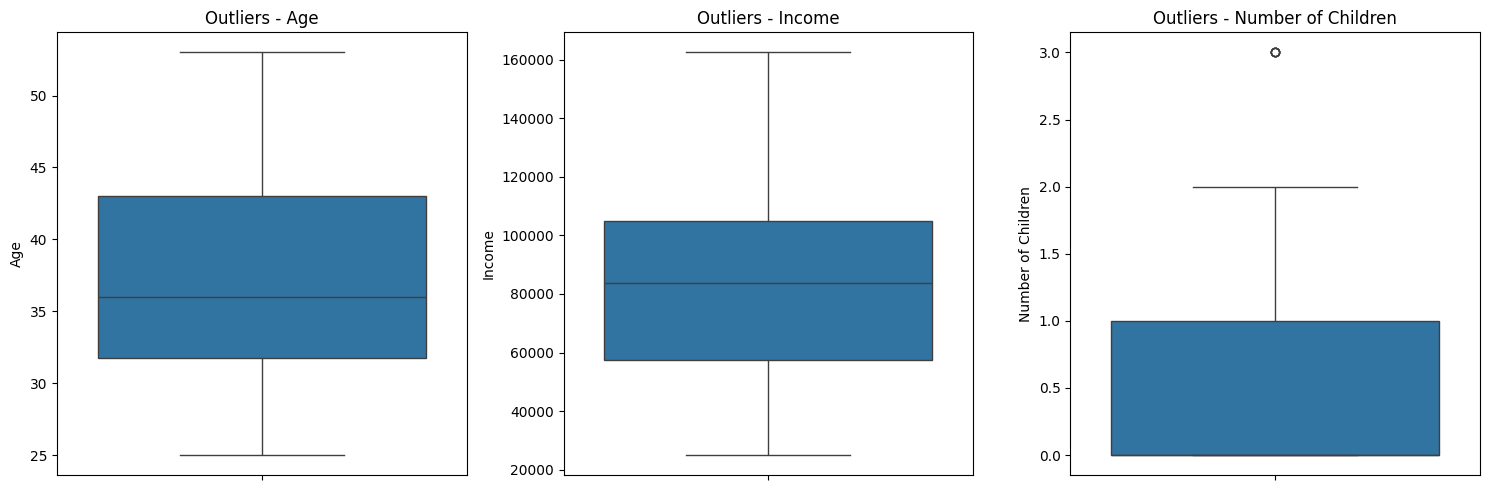

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df['Age'], ax=axes[0])
axes[0].set_title('Outliers - Age')

sns.boxplot(y=df['Income'], ax=axes[1])
axes[1].set_title('Outliers - Income')

sns.boxplot(y=df['Number of Children'], ax=axes[2])
axes[2].set_title('Outliers - Number of Children')

plt.tight_layout()
plt.show()

In [50]:
Q1_income = df['Income'].quantile(0.25)
Q3_income = df['Income'].quantile(0.75)

IQR_income = Q3_income - Q1_income

limite_inferior_income = Q1_income - 1.5 * IQR_income
limite_superior_income = Q3_income + 1.5 * IQR_income

print('Limite inferior:', limite_inferior_income)
print('Limite superior:', limite_superior_income)

Limite inferior: -13750.0
Limite superior: 176250.0


In [51]:
outliers_income = df[
    (df['Income'] < limite_inferior_income) |
    (df['Income'] > limite_superior_income)
]

outliers_income[['Income', 'Credit Score']]

,Income,Credit Score


Justificativa: A distribuição das idades apresenta maior concentração na região central da distribuição, sem valores visualmente muito distantes dos demais. Não é observada uma quantidade expressiva de possíveis valores extremos. Acontece o mesmo para Income, apesar de mostrar uma distribuição mais espalhada, não foi identificado outlier.
A distribuição está fortemente concentrada nos valores mais baixos, especialmente em zero filhos. Os valores maiores aparecem com frequência bem menor, formando uma distribuição assimétrica à direita.

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

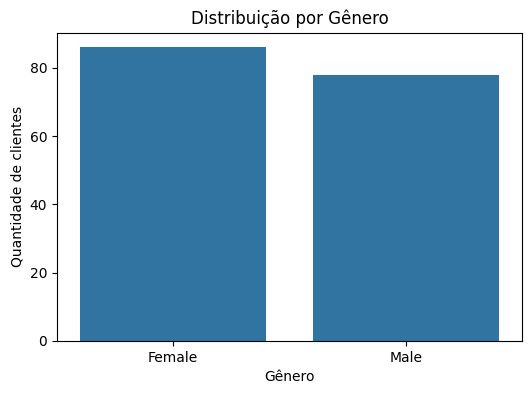

In [52]:
#seu código aqui
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender')
plt.title('Distribuição por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de clientes')
plt.show()

Insight: A distribuição por gênero é relativamente equilibrada. Portanto, não há uma predominância significativa de um dos gêneros na base analisada.

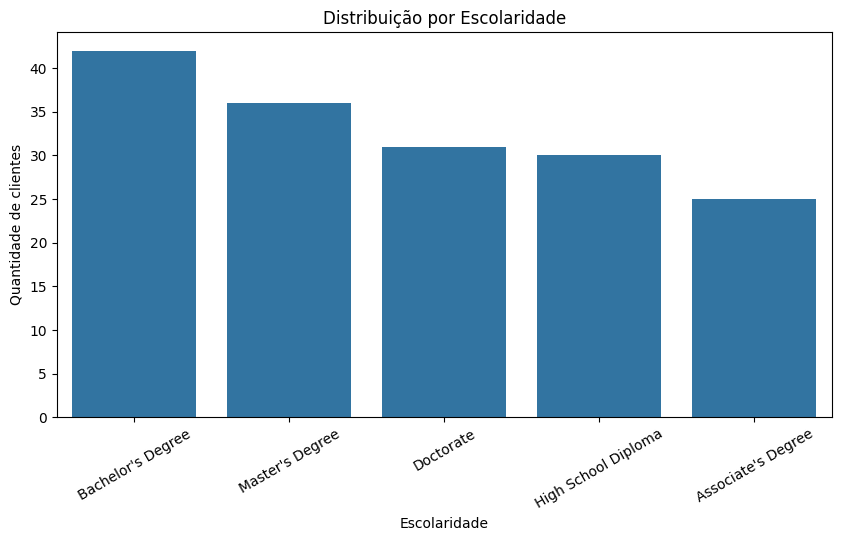

In [53]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Education')
plt.title('Distribuição por Escolaridade')
plt.xlabel('Escolaridade')
plt.ylabel('Quantidade de clientes')
plt.xticks(rotation=30)
plt.show()

Insight: A distribuição apresenta maior concentração nas categorias Bachelor's Degree e Master's Degree, enquanto Associate's Degree apresenta a menor frequência. As demais categorias possuem uma distribuição relativamente próxima entre si.

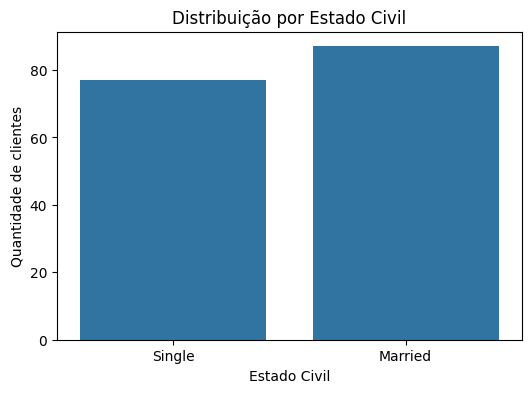

In [54]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Marital Status')
plt.title('Distribuição por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Quantidade de clientes')
plt.show()

Insight: O gráfico apresenta uma distribuição bastante equilibrada entre clientes casados e solteiros, sem predominância visual muito acentuada de uma das categorias.

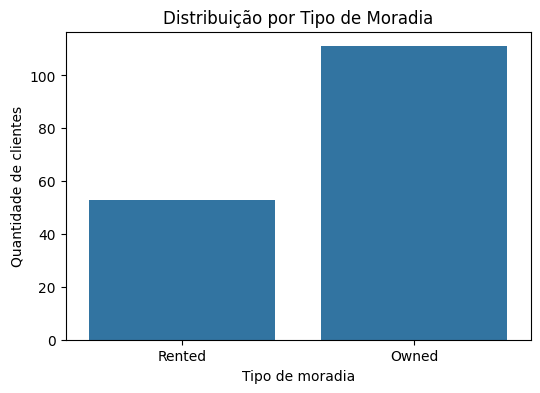

In [55]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Home Ownership')
plt.title('Distribuição por Tipo de Moradia')
plt.xlabel('Tipo de moradia')
plt.ylabel('Quantidade de clientes')
plt.show()

Insight: Observa-se uma predominância clara de clientes que possuem imóvel próprio em relação aos que residem em imóvel alugado.

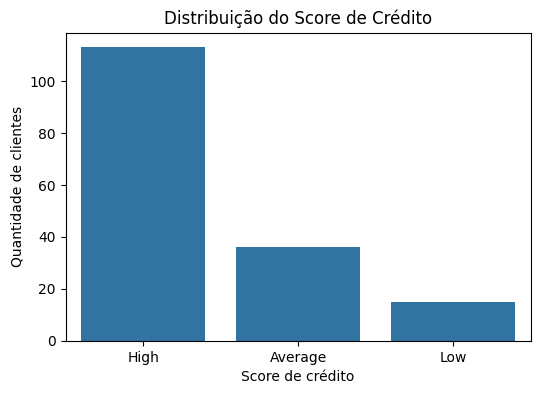

In [56]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Credit Score')
plt.title('Distribuição do Score de Crédito')
plt.xlabel('Score de crédito')
plt.ylabel('Quantidade de clientes')
plt.show()

Insight: O gráfico evidencia um forte desbalanceamento entre as classes de score. A categoria High apresenta uma predominância muito maior, enquanto Low é a categoria menos representada.

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [57]:
df[['Age', 'Income', 'Number of Children']].describe()

,Age,Income,Number of Children
count,164.0,164.000000,164.000000
mean,37.195122,83765.243902,0.652439
std,7.586619,32457.306728,0.883346
min,25.0,25000.000000,0.000000
25%,31.75,57500.000000,0.000000
50%,36.0,83750.000000,0.000000
75%,43.0,105000.000000,1.000000
max,53.0,162500.000000,3.000000


In [58]:
variaveis_numericas = ['Age', 'Income', 'Number of Children']

for coluna in variaveis_numericas:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ]

    print(f'\n{coluna}')
    print(f'Limite inferior: {limite_inferior}')
    print(f'Limite superior: {limite_superior}')
    print(f'Quantidade de possíveis outliers: {len(outliers)}')


Age
Limite inferior: 14.875
Limite superior: 59.875
Quantidade de possíveis outliers: 0

Income
Limite inferior: -13750.0
Limite superior: 176250.0
Quantidade de possíveis outliers: 0

Number of Children
Limite inferior: -1.5
Limite superior: 2.5
Quantidade de possíveis outliers: 5


Justificativa: Foi utilizado o método do intervalo interquartil (IQR) para identificação de possíveis outliers nas variáveis numéricas. A variável Age não apresentou valores fora dos limites estabelecidos pelo método, assim como Income. Na variável Number of Children, os registros com 3 filhos foram identificados como possíveis outliers estatísticos. Entretanto, esses valores são plausíveis e não indicam inconsistência nos dados. Portanto, optou-se por manter esses registros na base, evitando a exclusão de informações potencialmente relevantes.

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



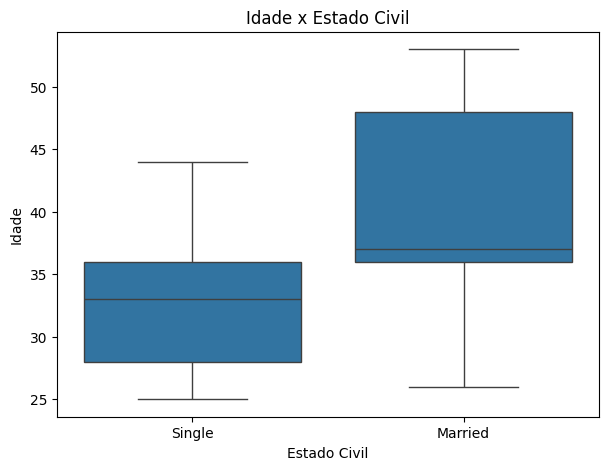

In [59]:
#1
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='Marital Status', y='Age')

plt.title('Idade x Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Idade')
plt.show()

Insight: O gráfico indica uma diferença na distribuição das idades entre os dois grupos. Os clientes casados tendem a apresentar idades mais elevadas, enquanto os solteiros apresentam maior concentração nas idades mais baixas. Portanto, existe uma possível relação entre idade e estado civil na base analisada.

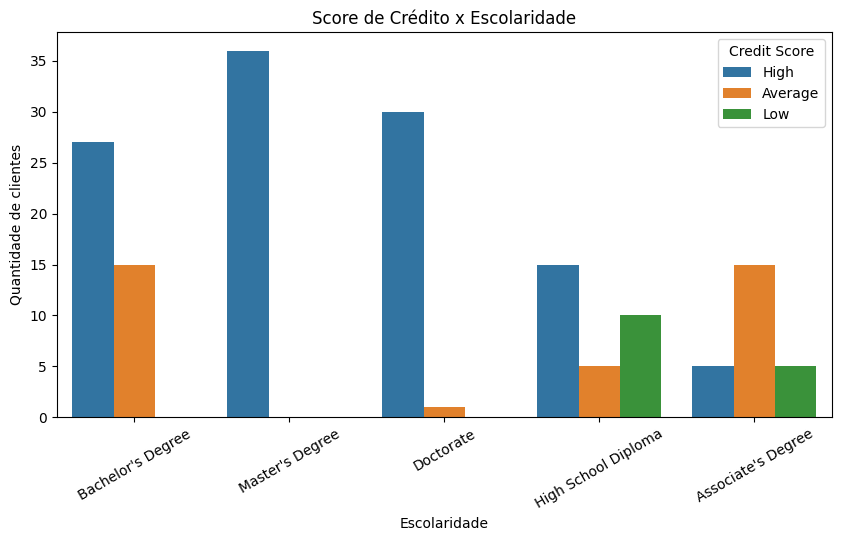

In [60]:
#2
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Education',
    hue='Credit Score'
)

plt.title('Score de Crédito x Escolaridade')
plt.xlabel('Escolaridade')
plt.ylabel('Quantidade de clientes')
plt.xticks(rotation=30)
plt.legend(title='Credit Score')
plt.show()

Insight: O gráfico mostra que as diferentes categorias de escolaridade apresentam clientes distribuídos entre os diferentes níveis de score. Apesar de existirem diferenças na composição das categorias, não é possível observar visualmente uma relação linear clara entre maior escolaridade e maior score de crédito. Portanto, apenas pela análise gráfica, a escolaridade não parece ser um dos fatores mais evidentes associados ao score.

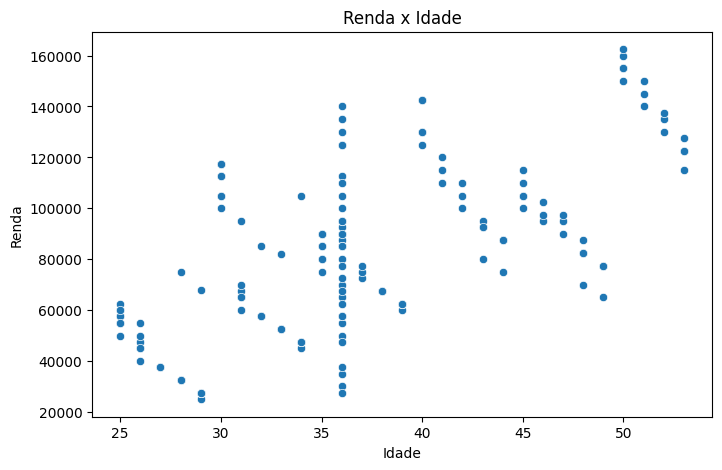

In [61]:
#3
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Income'
)

plt.title('Renda x Idade')
plt.xlabel('Idade')
plt.ylabel('Renda')
plt.show()

Insight: O gráfico apresenta uma tendência de aumento da renda conforme a idade aumenta. Embora existam algumas variações entre os indivíduos, observa-se uma concentração de rendas menores nas idades mais baixas e de rendas maiores nas idades mais elevadas. Isso sugere uma relação positiva entre idade e renda na base analisada.

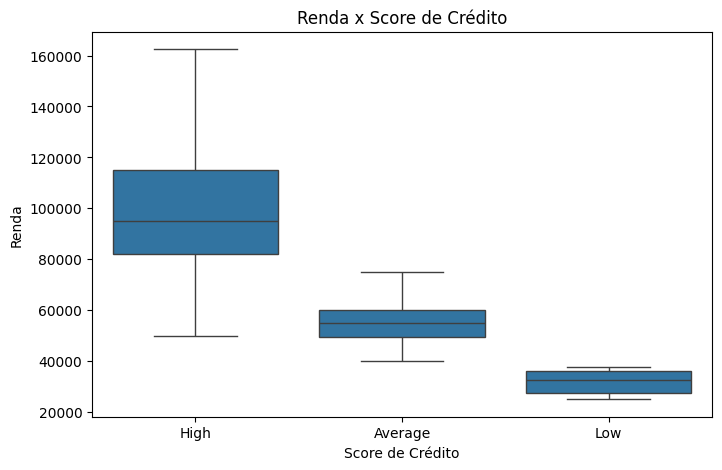

In [62]:
#4
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Credit Score',
    y='Income'
)

plt.title('Renda x Score de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Renda')
plt.show()

Insight: O gráfico indica uma diferença clara na distribuição da renda entre os níveis de score. Os clientes classificados com score High apresentam uma concentração de rendas mais elevadas, enquanto os grupos com score Average e Low apresentam distribuições de renda mais baixas. Dessa forma, a renda parece estar relacionada ao score de crédito nessa base.

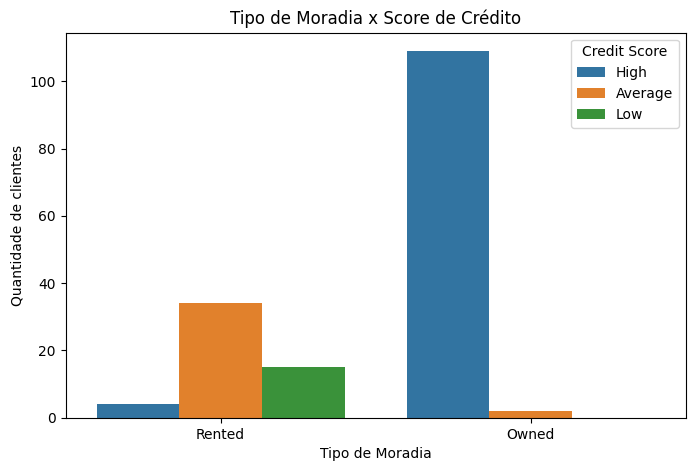

In [63]:
#5
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Home Ownership',
    hue='Credit Score'
)

plt.title('Tipo de Moradia x Score de Crédito')
plt.xlabel('Tipo de Moradia')
plt.ylabel('Quantidade de clientes')
plt.show()

Insight: O gráfico mostra uma diferença bastante evidente na distribuição dos scores entre clientes que possuem casa própria e aqueles que residem em imóvel alugado. Entre os clientes com casa própria, há uma predominância visual muito maior da categoria High, enquanto entre os clientes que alugam a distribuição dos scores é mais diversificada. Dessa forma, a posse de imóvel parece estar associada a scores de crédito mais altos nessa base.

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

1. O número de filhos parece estar relacionado ao score de crédito?
2. Existe diferença no score de crédito entre homens e mulheres?
3. O estado civil parece estar relacionado ao score de crédito?

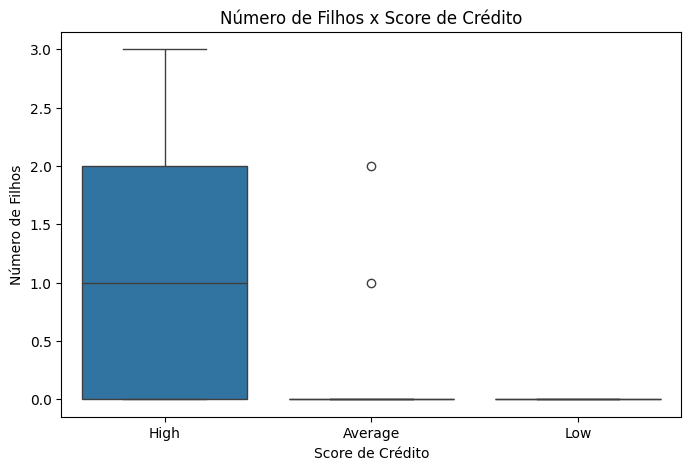

In [64]:
# seu código aqui
#1
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Credit Score',
    y='Number of Children'
)

plt.title('Número de Filhos x Score de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Número de Filhos')
plt.show()

Insight: O gráfico indica uma diferença na distribuição do número de filhos entre os níveis de score de crédito. Clientes classificados como High apresentam maior quantidade e maior dispersão no número de filhos, enquanto os grupos Average e Low estão predominantemente concentrados em zero filhos. Dessa forma, o número de filhos parece apresentar alguma relação com o score de crédito nessa base, embora esse resultado deva ser interpretado com cautela.

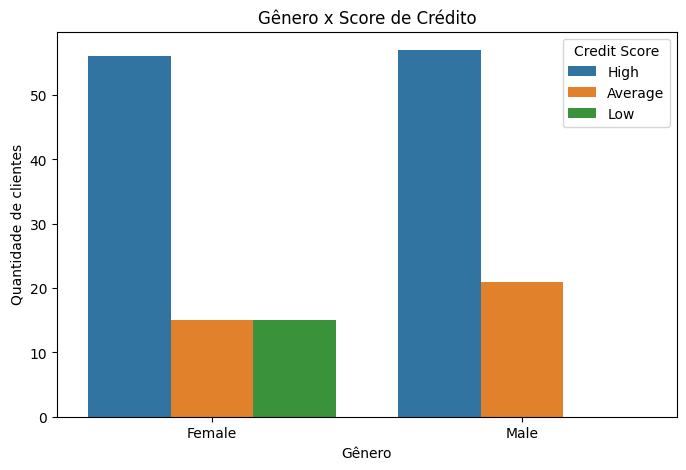

In [65]:
#2
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Credit Score'
)

plt.title('Gênero x Score de Crédito')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de clientes')
plt.show()

Insight: O gráfico permite comparar a distribuição dos diferentes níveis de score entre homens e mulheres. Visualmente, a categoria High predomina nos dois grupos, indicando que o gênero, isoladamente, não apresenta uma diferença muito evidente na distribuição geral do score de crédito. Porém é possível ver que só existem Low em Female

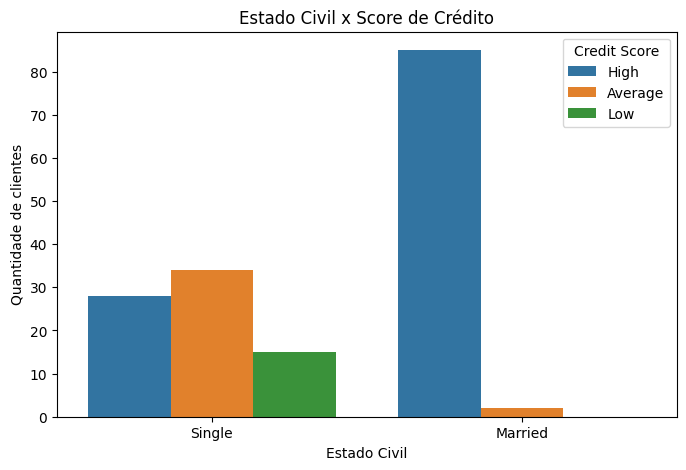

In [66]:
#3
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Marital Status',
    hue='Credit Score'
)

plt.title('Estado Civil x Score de Crédito')
plt.xlabel('Estado Civil')
plt.ylabel('Quantidade de clientes')
plt.show()

Insight: O gráfico mostra uma diferença bastante evidente na distribuição do score de crédito entre os estados civis. Entre os clientes solteiros, os três níveis de score estão representados, enquanto entre os clientes casados há uma forte predominância do score High. Dessa forma, o estado civil parece apresentar uma relação importante com o score de crédito nessa base, sendo que os clientes casados estão predominantemente associados à classificação High.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

In [67]:
#seu código aqui
correlacao = df[['Age', 'Income', 'Number of Children']].corr()

correlacao

,Age,Income,Number of Children
Age,1.000000,0.621492,0.072432
Income,0.621492,1.000000,0.084547
Number of Children,0.072432,0.084547,1.000000


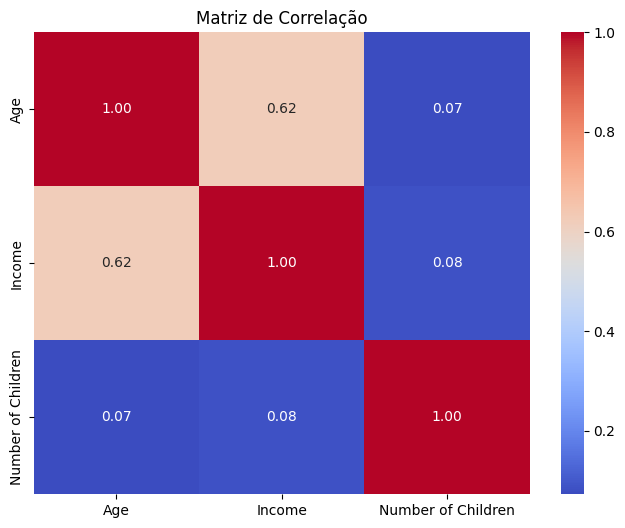

In [68]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

A maior correlação encontrada foi entre as variáveis Age e Income, com valor de 0,62, indicando uma correlação positiva moderada. Isso significa que, nessa base, existe uma tendência de clientes mais velhos apresentarem rendas maiores. Essa relação parece fazer sentido, pois o aumento da idade pode estar associado a maior experiência profissional e, consequentemente, maiores rendimentos. Entretanto, a correlação indica apenas uma associação entre as variáveis e não permite afirmar que uma seja responsável pelo aumento da outra.

As correlações entre Number of Children e Age (0,07) e entre Number of Children e Income (0,08) são muito baixas, indicando pouca ou nenhuma relação linear entre essas variáveis.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [69]:
#seu código aqui
colunas_categoricas = [
    'Gender',
    'Education',
    'Marital Status',
    'Home Ownership'
]

In [70]:
df = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=False
)

In [71]:
df.head()

,Age,Income,Number of Children,Credit Score,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,25,50000.0,0,High,True,False,False,True,False,False,False,False,True,False,True
1,30,100000.0,2,High,False,True,False,False,False,False,True,True,False,True,False
2,35,75000.0,1,High,True,False,False,False,True,False,False,True,False,True,False
3,40,125000.0,0,High,False,True,False,False,False,True,False,False,True,True,False
4,45,100000.0,3,High,True,False,False,True,False,False,False,True,False,True,False


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            164 non-null    Int64  
 1   Income                         164 non-null    float64
 2   Number of Children             164 non-null    int64  
 3   Credit Score                   164 non-null    object 
 4   Gender_Female                  164 non-null    bool   
 5   Gender_Male                    164 non-null    bool   
 6   Education_Associate's Degree   164 non-null    bool   
 7   Education_Bachelor's Degree    164 non-null    bool   
 8   Education_Doctorate            164 non-null    bool   
 9   Education_High School Diploma  164 non-null    bool   
 10  Education_Master's Degree      164 non-null    bool   
 11  Marital Status_Married         164 non-null    bool   
 12  Marital Status_Single          164 non-null    boo

In [73]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Credit Score'] = le.fit_transform(df['Credit Score'])

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            164 non-null    Int64  
 1   Income                         164 non-null    float64
 2   Number of Children             164 non-null    int64  
 3   Credit Score                   164 non-null    int64  
 4   Gender_Female                  164 non-null    bool   
 5   Gender_Male                    164 non-null    bool   
 6   Education_Associate's Degree   164 non-null    bool   
 7   Education_Bachelor's Degree    164 non-null    bool   
 8   Education_Doctorate            164 non-null    bool   
 9   Education_High School Diploma  164 non-null    bool   
 10  Education_Master's Degree      164 non-null    bool   
 11  Marital Status_Married         164 non-null    bool   
 12  Marital Status_Single          164 non-null    boo

In [75]:
df.columns

Index(['Age', 'Income', 'Number of Children', 'Credit Score', 'Gender_Female',
       'Gender_Male', 'Education_Associate's Degree',
       'Education_Bachelor's Degree', 'Education_Doctorate',
       'Education_High School Diploma', 'Education_Master's Degree',
       'Marital Status_Married', 'Marital Status_Single',
       'Home Ownership_Owned', 'Home Ownership_Rented'],
      dtype='object')

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

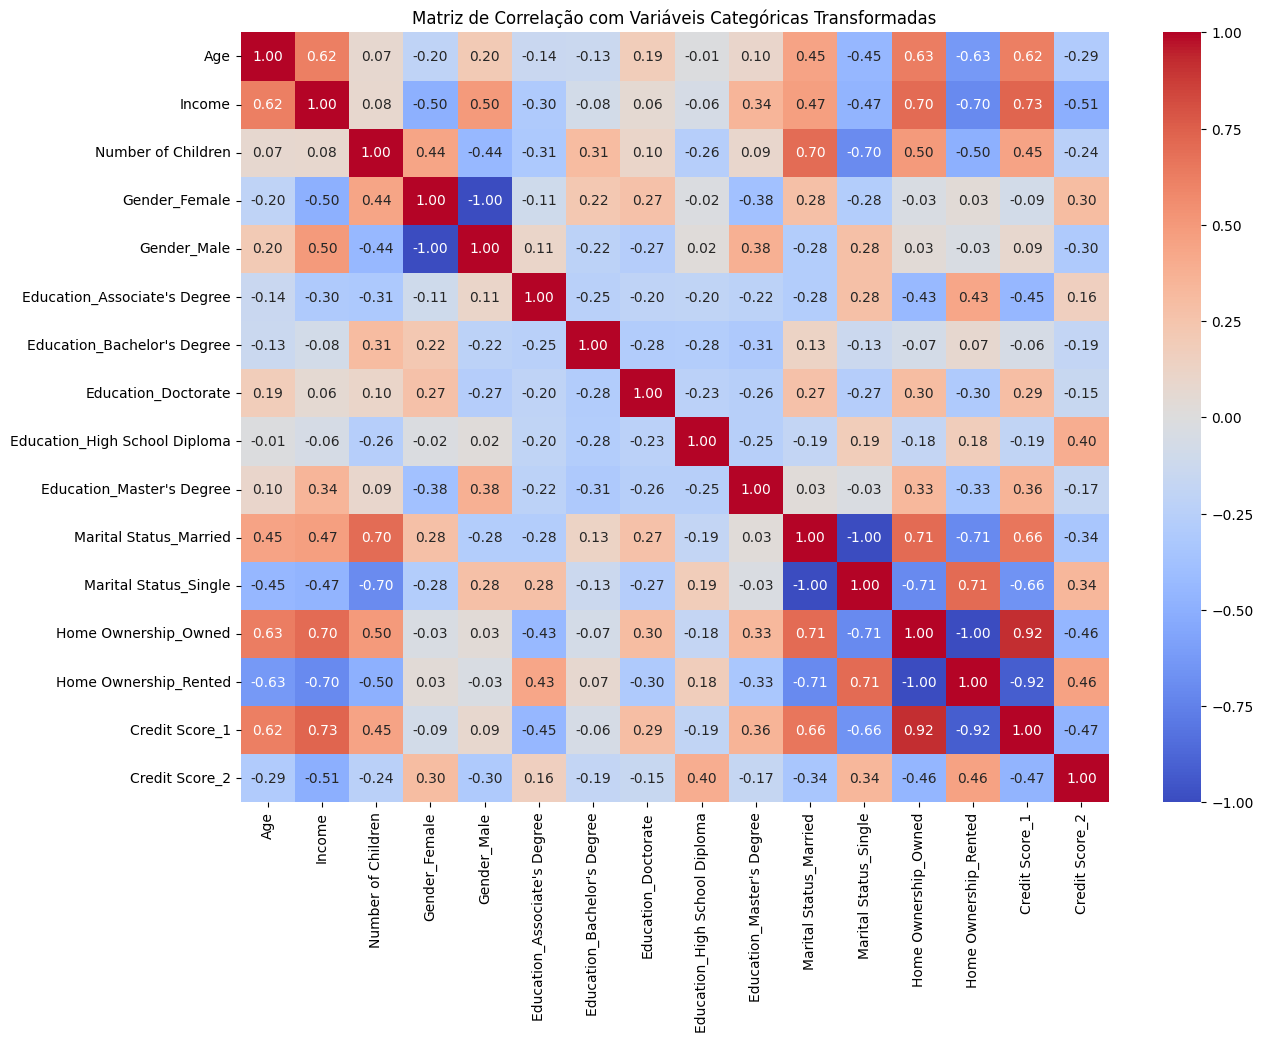

In [76]:
#seu código aqui
# Criando uma cópia apenas para a análise de correlação
df_correlacao = df.copy()

# Transformando o Credit Score em variáveis numéricas
df_correlacao = pd.get_dummies(
    df_correlacao,
    columns=['Credit Score'],
    drop_first=True,
    dtype=int
)

# Calculando a matriz de correlação
correlacao = df_correlacao.corr()

# Plotando o heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação com Variáveis Categóricas Transformadas')
plt.show()

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [77]:
#seu código aqui
X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [79]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (131, 14)
X_test: (33, 14)
y_train: (131,)
y_test: (33,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

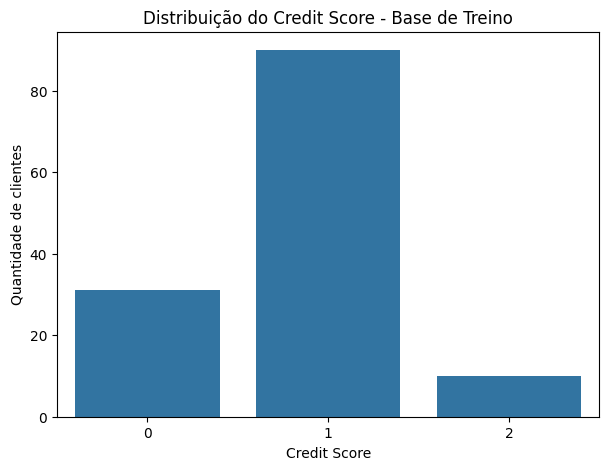

In [80]:
#seu código aqui
plt.figure(figsize=(7, 5))

sns.countplot(data=pd.DataFrame({'Credit Score': y_train}), x='Credit Score')

plt.title('Distribuição do Credit Score - Base de Treino')
plt.xlabel('Credit Score')
plt.ylabel('Quantidade de clientes')

plt.show()

In [82]:
y_train.value_counts(normalize=True) * 100

,proportion
Credit Score,
1,68.702290
0,23.664122
2,7.633588


Justificativa: O gráfico evidencia um desbalanceamento na variável Credit Score. A classe High apresenta uma quantidade de observações significativamente maior que as classes Average e Low, sendo Low a classe minoritária. Esse desbalanceamento pode prejudicar o desempenho do modelo na identificação das classes menos representadas. Por esse motivo, será necessário realizar o balanceamento da base de treino na próxima etapa.

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [83]:
#seu código aqui
from imblearn.over_sampling import RandomOverSampler

In [84]:
ros = RandomOverSampler(random_state=42)

X_train_balanceado, y_train_balanceado = ros.fit_resample(
    X_train,
    y_train
)

In [85]:
print('Antes do balanceamento:')
print(y_train.value_counts())

print('\nDepois do balanceamento:')
print(y_train_balanceado.value_counts())

Antes do balanceamento:
Credit Score
1    90
0    31
2    10
Name: count, dtype: int64

Depois do balanceamento:
Credit Score
1    90
0    90
2    90
Name: count, dtype: int64


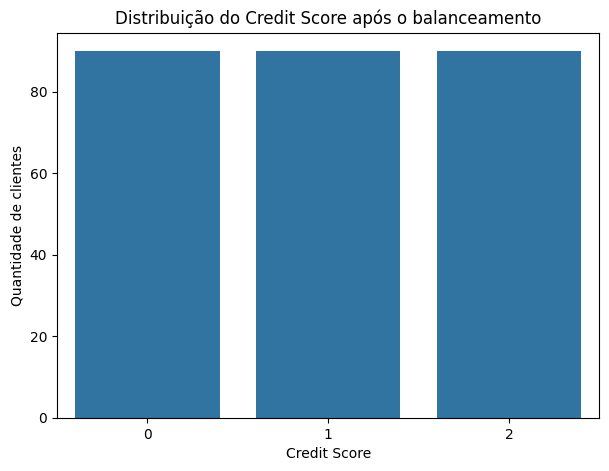

In [86]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train_balanceado
)

plt.title('Distribuição do Credit Score após o balanceamento')
plt.xlabel('Credit Score')
plt.ylabel('Quantidade de clientes')

plt.show()

Foi aplicado o método RandomOverSampler exclusivamente na base de treino, aumentando a quantidade de observações das classes minoritárias até que todas as categorias do Credit Score apresentassem a mesma representatividade. A base de teste não foi alterada, pois deve permanecer com sua distribuição original para permitir uma avaliação mais adequada do modelo.